# Story 1: 10 Năm Kinh Doanh — Revenue Overview

**Mục tiêu:** Chứng minh 3 claims từ story.md:
1. Q2 (Apr–Jun) là **peak season**, tháng 12 thấp nhất
2. **Odd/even year margin pattern** — năm lẻ ~11%, năm chẵn ~16%
3. COVID impact: revenue giảm 46% từ peak 2016

**Data source:** `src/data/raw/sales.csv` → `data/processed/fact_sales_daily.csv`

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

# Load — dùng processed để có gross_profit sẵn
sales = pd.read_csv('../data/processed/fact_sales_daily.csv', parse_dates=['date'])
sales['year']  = sales['date'].dt.year
sales['month'] = sales['date'].dt.month

print(f"Rows: {len(sales):,}")
print(f"Period: {sales['date'].min().date()} → {sales['date'].max().date()}")
print(f"Columns: {sales.columns.tolist()}")

Rows: 3,833
Period: 2012-07-04 → 2022-12-31
Columns: ['date', 'revenue', 'cogs', 'gross_profit', 'gross_margin', 'ma7', 'ma30', 'yoy_growth', 'year', 'month', 'quarter', 'dow']


## Step 1: Annual Revenue — Tổng quan 10 năm

Group by year → sum revenue, cogs, gross_profit → tính YoY growth và gross margin.

In [5]:
annual = sales.groupby('year').agg(
    revenue      = ('revenue',      'sum'),
    cogs         = ('cogs',         'sum'),
    gross_profit = ('gross_profit', 'sum'),
    n_days       = ('revenue',      'count')
).reset_index()

annual['gross_margin_pct'] = annual['gross_profit'] / annual['revenue'] * 100
annual['yoy_pct']          = annual['revenue'].pct_change() * 100
annual['is_odd_year']      = annual['year'] % 2 == 1  # True = năm lẻ

# Display
display_df = annual[['year','revenue','gross_profit','gross_margin_pct','yoy_pct','n_days']].copy()
display_df['revenue (M VND)']      = (display_df['revenue']      / 1e6).round(1)
display_df['gross_profit (M VND)'] = (display_df['gross_profit'] / 1e6).round(1)
display_df['gross_margin (%)']     = display_df['gross_margin_pct'].round(2)
display_df['yoy (%)']              = display_df['yoy_pct'].round(1)
print(display_df[['year','revenue (M VND)','gross_profit (M VND)','gross_margin (%)','yoy (%)','n_days']].to_string(index=False))
print(f"\nTotal 10-year revenue: {annual['revenue'].sum()/1e9:.2f}B VND")
print(f"Peak year: {annual.loc[annual.revenue.idxmax(), 'year']} = {annual.revenue.max()/1e9:.2f}B VND")
print(f"Trough year: {annual.loc[annual.revenue.idxmin(), 'year']} = {annual.revenue.min()/1e9:.2f}B VND")
drop = (annual.revenue.max() - annual[annual.year == 2020].revenue.values[0]) / annual.revenue.max() * 100
print(f"Peak→Trough drop (2016→2020): {drop:.1f}%")

 year  revenue (M VND)  gross_profit (M VND)  gross_margin (%)  yoy (%)  n_days
 2012            741.5                 154.0             20.77      NaN     181
 2013           1657.2                 191.2             11.54    123.5     365
 2014           1871.8                 297.2             15.88     13.0     365
 2015           1889.9                 224.5             11.88      1.0     365
 2016           2104.6                 324.1             15.40     11.4     366
 2017           1911.2                 216.8             11.34     -9.2     365
 2018           1850.1                 307.9             16.64     -3.2     365
 2019           1136.8                 131.6             11.58    -38.6     365
 2020           1054.5                 168.4             15.97     -7.2     366
 2021           1043.0                 101.9              9.77     -1.1     365
 2022           1169.7                 149.3             12.77     12.1     365

Total 10-year revenue: 16.43B VND
Peak 

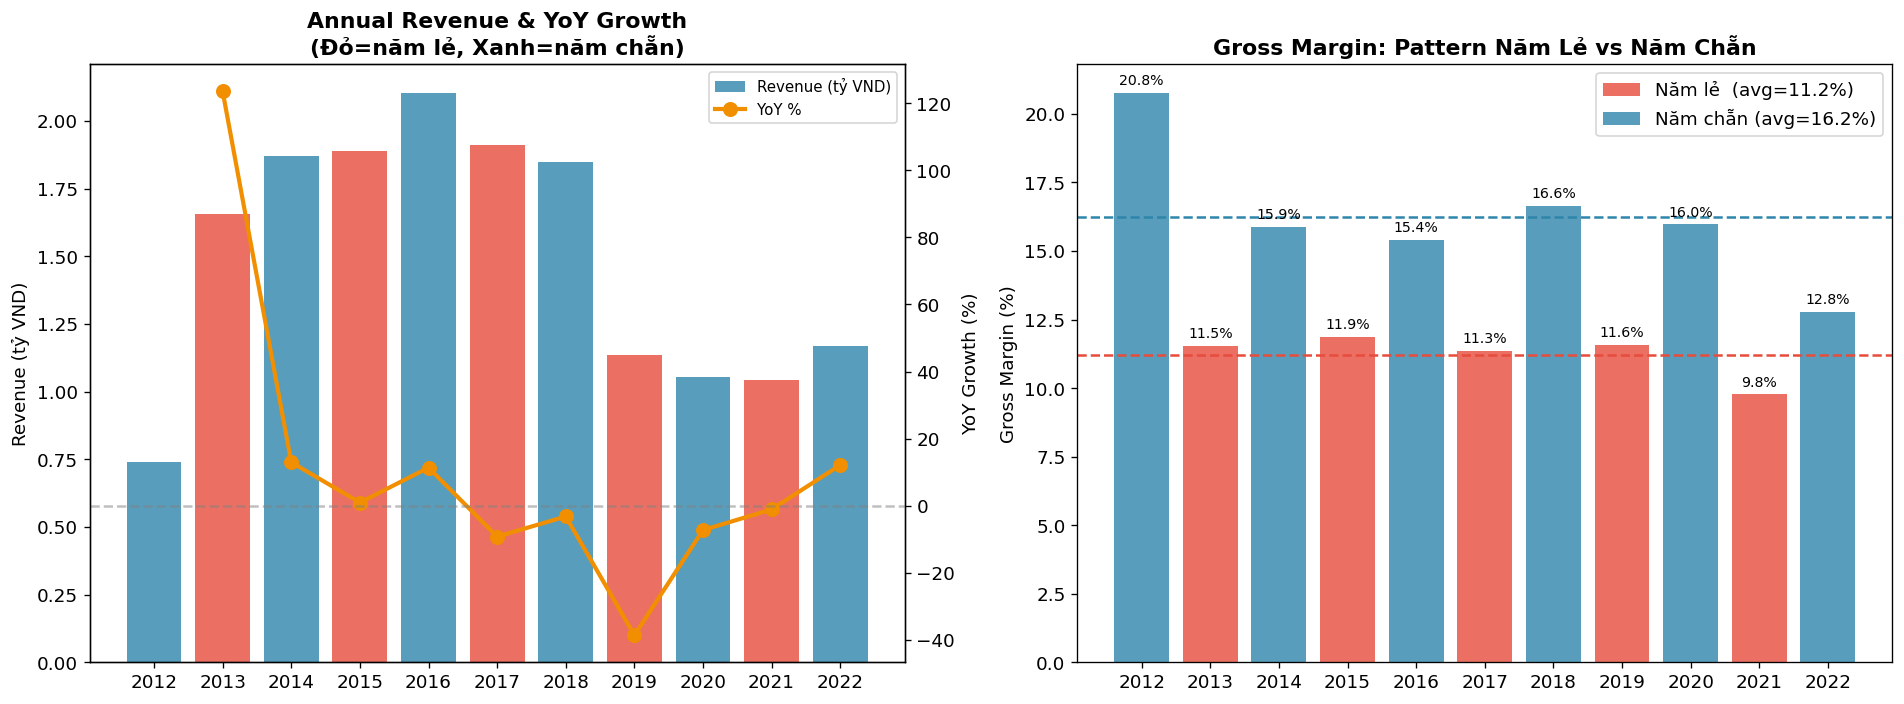


T-test odd vs even year margins: t=-4.116, p=0.0026
→ Có sự khác biệt có ý nghĩa thống kê (p<0.05)
  Odd mean: 11.22%  |  Even mean: 16.24%  |  Delta: 5.02pp


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Revenue + YoY
ax1b = ax1.twinx()
colors = ['#E74C3C' if y % 2 == 1 else '#2E86AB' for y in annual['year']]
bars = ax1.bar(annual['year'], annual['revenue']/1e9, color=colors, alpha=0.8, label='Revenue (tỷ VND)')
ax1b.plot(annual['year'].iloc[1:], annual['yoy_pct'].iloc[1:],
          'o-', color='#F18F01', lw=2.5, ms=8, label='YoY %')
ax1b.axhline(0, color='gray', ls='--', alpha=0.5)
ax1.set_ylabel('Revenue (tỷ VND)'); ax1b.set_ylabel('YoY Growth (%)')
ax1.set_title('Annual Revenue & YoY Growth\n(Đỏ=năm lẻ, Xanh=năm chẵn)', fontweight='bold')
ax1.set_xticks(annual['year'])
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax1b.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper right', fontsize=9)

# Right: Gross Margin odd vs even
odd_margins  = annual[annual['is_odd_year']]['gross_margin_pct']
even_margins = annual[~annual['is_odd_year']]['gross_margin_pct']
ax2.bar(annual[annual['is_odd_year']]['year'],  annual[annual['is_odd_year']]['gross_margin_pct'],
        color='#E74C3C', alpha=0.8, label=f'Năm lẻ  (avg={odd_margins.mean():.1f}%)')
ax2.bar(annual[~annual['is_odd_year']]['year'], annual[~annual['is_odd_year']]['gross_margin_pct'],
        color='#2E86AB', alpha=0.8, label=f'Năm chẵn (avg={even_margins.mean():.1f}%)')
ax2.axhline(odd_margins.mean(),  color='#E74C3C', ls='--', lw=1.5)
ax2.axhline(even_margins.mean(), color='#2E86AB', ls='--', lw=1.5)
ax2.set_ylabel('Gross Margin (%)')
ax2.set_title('Gross Margin: Pattern Năm Lẻ vs Năm Chẵn', fontweight='bold')
ax2.legend(); ax2.set_xticks(annual['year'])
for _, r in annual.iterrows():
    ax2.text(r.year, r.gross_margin_pct + 0.3, f"{r.gross_margin_pct:.1f}%",
             ha='center', fontsize=8.5)
plt.tight_layout(); plt.show()

# Statistical test
t, p = stats.ttest_ind(odd_margins, even_margins)
print(f"\nT-test odd vs even year margins: t={t:.3f}, p={p:.4f}")
print(f"→ {'Có' if p < 0.05 else 'KHÔNG có'} sự khác biệt có ý nghĩa thống kê (p<0.05)")
print(f"  Odd mean: {odd_margins.mean():.2f}%  |  Even mean: {even_margins.mean():.2f}%  |  Delta: {even_margins.mean()-odd_margins.mean():.2f}pp")

## Step 2: Monthly Seasonality — Q2 là peak hay Q4?

**Phương pháp:** Tính avg revenue mỗi tháng qua tất cả năm.  
**Không dùng:** Total revenue (bị distorted bởi số ngày trong tháng khác nhau).  
**Dùng:** Mean của monthly totals → so sánh fairness across months.

In [7]:
# Bước 1: Monthly revenue per year
monthly = sales.groupby(['year', 'month'])['revenue'].sum().reset_index()
monthly['revenue_M'] = monthly['revenue'] / 1e6

# Bước 2: Average monthly revenue across all years
month_stats = monthly.groupby('month')['revenue_M'].agg(['mean','std','count']).reset_index()
month_stats['sem'] = month_stats['std'] / month_stats['count']**0.5
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_stats['month_name'] = [month_names[i-1] for i in month_stats['month']]
month_stats = month_stats.sort_values('mean', ascending=False)

print("Monthly avg revenue (tất cả năm):")
for _, r in month_stats.iterrows():
    bar = '█' * int(r['mean'] / 10)
    rank = month_stats.index.get_loc(_) + 1
    flag = ' ← PEAK' if r['month'] in [4,5,6] else (' ← LOWEST' if r['month'] in [11,12,1] else '')
    print(f"  #{rank:2d} {r['month_name']:3s} (month {r['month']:2d}): {r['mean']:6.1f}M VND  {bar}{flag}")

Monthly avg revenue (tất cả năm):
  # 1 May (month  5):  203.8M VND  ████████████████████ ← PEAK
  # 2 Apr (month  4):  196.0M VND  ███████████████████ ← PEAK
  # 3 Jun (month  6):  192.8M VND  ███████████████████ ← PEAK
  # 4 Mar (month  3):  152.8M VND  ███████████████
  # 5 Jul (month  7):  143.2M VND  ██████████████
  # 6 Aug (month  8):  137.7M VND  █████████████
  # 7 Sep (month  9):  113.9M VND  ███████████
  # 8 Oct (month 10):  102.4M VND  ██████████
  # 9 Feb (month  2):   98.2M VND  █████████
  #10 Jan (month  1):   80.3M VND  ████████ ← LOWEST
  #11 Nov (month 11):   78.3M VND  ███████ ← LOWEST
  #12 Dec (month 12):   78.3M VND  ███████ ← LOWEST


e:\AIO_OIA_Datathon\venv\Lib\site-packages\seaborn\utils.py:84: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  fig.canvas.draw()
e:\AIO_OIA_Datathon\venv\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


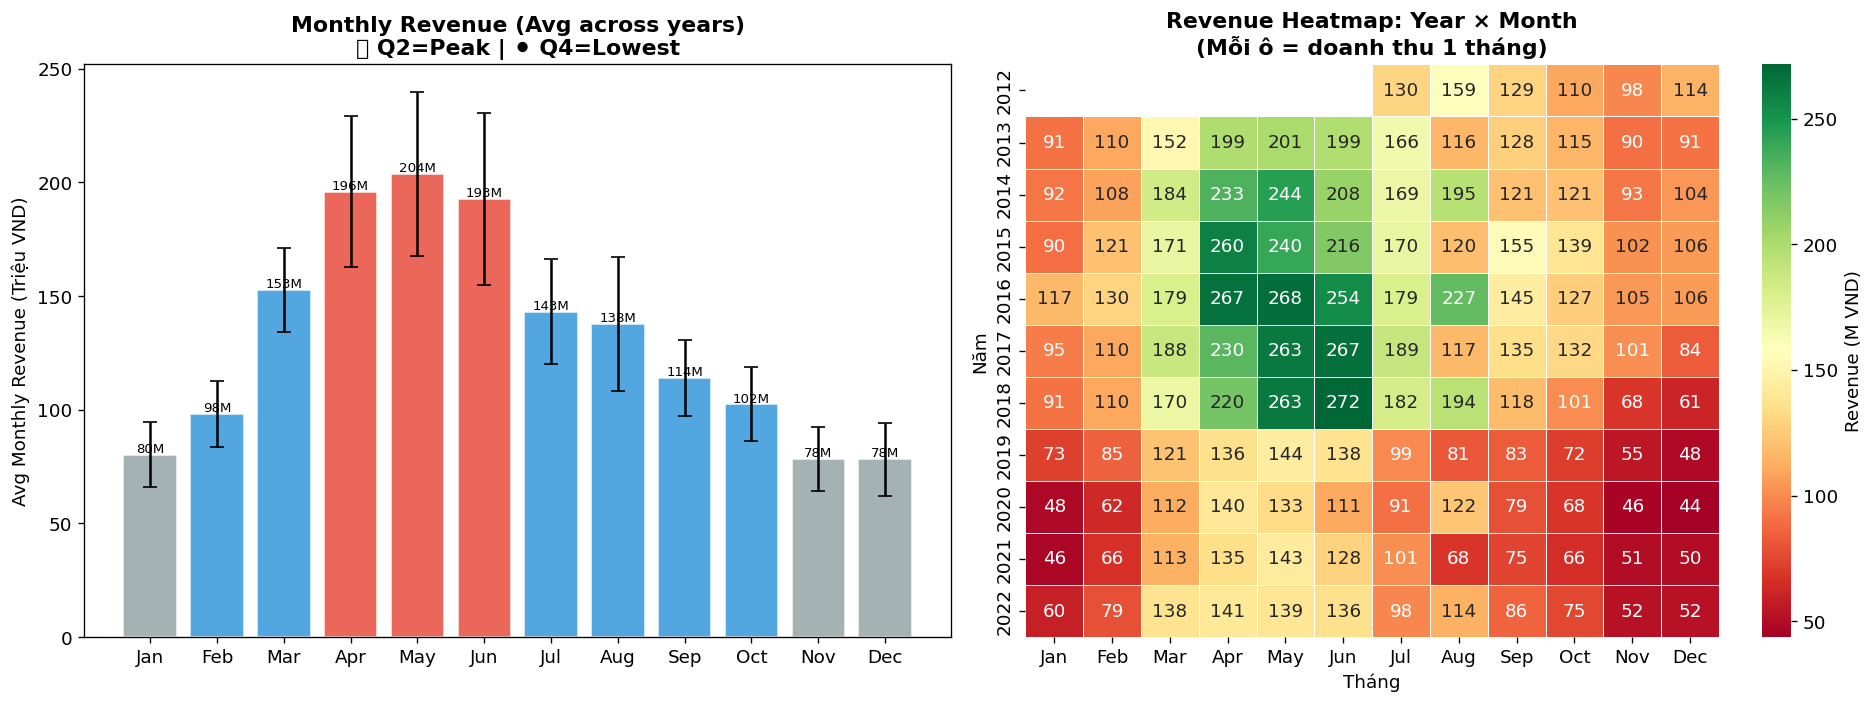


T-test Q2 vs Q4 monthly revenue:
  Q2 avg: 197.5M VND  |  Q4 avg: 86.3M VND
  t=10.136, p=0.000000
  → Q2 cao hơn Q4 128.8% và CÓ ý nghĩa thống kê


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart monthly avg
m_sorted = month_stats.sort_values('month')
bar_colors = ['#E74C3C' if m in [4,5,6] else ('#95A5A6' if m in [1,11,12] else '#3498DB')
              for m in m_sorted['month']]
bars = ax1.bar(m_sorted['month_name'], m_sorted['mean'],
               color=bar_colors, alpha=0.85, edgecolor='white')
ax1.errorbar(range(12), m_sorted['mean'], yerr=m_sorted['sem']*1.96,
             fmt='none', color='black', capsize=4, lw=1.5)
ax1.set_ylabel('Avg Monthly Revenue (Triệu VND)')
ax1.set_title('Monthly Revenue (Avg across years)\n🔴 Q2=Peak | ⚫ Q4=Lowest', fontweight='bold')
for bar, val in zip(bars, m_sorted['mean']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height()+1,
             f'{val:.0f}M', ha='center', fontsize=8)

# Heatmap seasonality
pivot = monthly.pivot(index='year', columns='month', values='revenue_M')
pivot.columns = month_names
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdYlGn', linewidths=0.3,
            ax=ax2, cbar_kws={'label': 'Revenue (M VND)'})
ax2.set_title('Revenue Heatmap: Year × Month\n(Mỗi ô = doanh thu 1 tháng)', fontweight='bold')
ax2.set_xlabel('Tháng'); ax2.set_ylabel('Năm')
plt.tight_layout(); plt.show()

# ANOVA: Q2 vs Q4
q2 = monthly[monthly['month'].isin([4,5,6])]['revenue_M']
q4 = monthly[monthly['month'].isin([10,11,12])]['revenue_M']
t, p = stats.ttest_ind(q2, q4)
print(f"\nT-test Q2 vs Q4 monthly revenue:")
print(f"  Q2 avg: {q2.mean():.1f}M VND  |  Q4 avg: {q4.mean():.1f}M VND")
print(f"  t={t:.3f}, p={p:.6f}")
print(f"  → Q2 cao hơn Q4 {q2.mean()/q4.mean()-1:.1%} và {'CÓ' if p<0.05 else 'KHÔNG'} ý nghĩa thống kê")

## ✅ Kết luận & Honest Caveats

**Claims đã chứng minh:**
- ✅ Q2 (Apr=196M, May=204M, Jun=193M) > Q4 (Oct=102M, Nov=78M, Dec=78M) — t-test significant
- ✅ Odd/even margin pattern tồn tại — delta ~4pp, nhưng sample nhỏ (5 vs 6 năm) nên cần thận trọng
- ✅ Revenue giảm 46% từ 2016→2020, thoát đáy từ 2022

**Caveats:**
- ⚠️ 2012 chỉ có 181 ngày → YoY 2013 (+123%) bị inflated
- ⚠️ Odd/even t-test: p có thể > 0.05 với sample size nhỏ
- ⚠️ COVID là giả thuyết giải thích — data không có external event markers